In [1]:
import os, glob

# look in the usual places
candidates = (
    glob.glob("/content/*.zip")
    + glob.glob("/content/drive/MyDrive/**/*.zip", recursive=True)
)

print("ZIP candidates found:")
for p in candidates:
    print(p)



ZIP candidates found:


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, zipfile, shutil

zip_path = "/content/Yelp-JSON.zip"
out_dir  = "/content/Yelp_JSON"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)

# remove macOS metadata folder if it exists
macosx_path = os.path.join(out_dir, "__MACOSX")
if os.path.exists(macosx_path):
    shutil.rmtree(macosx_path)

print("Unzipped to:", out_dir)
print("Top-level:", os.listdir(out_dir))


FileNotFoundError: [Errno 2] No such file or directory: '/content/Yelp-JSON.zip'

In [ ]:
import os
import glob

base = "/content/Yelp_JSON"  # where you extracted

print("Folders under base:")
for p in glob.glob(base + "/*"):
    print(p)

print("\nAll files under base (first 200):")
all_files = glob.glob(base + "/**/*", recursive=True)
all_files = [p for p in all_files if os.path.isfile(p)]
for p in all_files[:200]:
    print(p)

print("\nCount files:", len(all_files))


Folders under base:
/content/Yelp_JSON/Yelp JSON

All files under base (first 200):
/content/Yelp_JSON/Yelp JSON/Yelp Dataset Documentation & ToS copy.pdf
/content/Yelp_JSON/Yelp JSON/yelp_dataset.tar

Count files: 2


In [ ]:
import os, tarfile

tar_path = "/content/Yelp_JSON/Yelp JSON/yelp_dataset.tar"
out_dir  = "/content/Yelp_extracted"

os.makedirs(out_dir, exist_ok=True)

with tarfile.open(tar_path, "r:*") as tar:
    tar.extractall(path=out_dir)

print("Extracted TAR to:", out_dir)

# list extracted files
import glob
files = [p for p in glob.glob(out_dir + "/**/*", recursive=True) if os.path.isfile(p)]
print("Number of files:", len(files))
for p in files[:50]:
    print(p)

/tmp/ipython-input-2848106920.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=out_dir)


Extracted TAR to: /content/Yelp_extracted
Number of files: 6
/content/Yelp_extracted/yelp_academic_dataset_tip.json
/content/Yelp_extracted/yelp_academic_dataset_review.json
/content/Yelp_extracted/yelp_academic_dataset_business.json
/content/Yelp_extracted/yelp_academic_dataset_checkin.json
/content/Yelp_extracted/Dataset_User_Agreement.pdf
/content/Yelp_extracted/yelp_academic_dataset_user.json


In [ ]:
import os, glob

base = "/content/Yelp_extracted"
all_files = [p for p in glob.glob(base + "/**/*", recursive=True) if os.path.isfile(p)]

def pick_file(keyword):
    matches = [p for p in all_files if keyword in os.path.basename(p).lower() and p.lower().endswith(".json")]
    return matches[0] if matches else None

business_path = pick_file("business")
review_path   = pick_file("review")
checkin_path  = pick_file("checkin")

print("business_path:", business_path)
print("review_path  :", review_path)
print("checkin_path :", checkin_path)

business_path: /content/Yelp_extracted/yelp_academic_dataset_business.json
review_path  : /content/Yelp_extracted/yelp_academic_dataset_review.json
checkin_path : /content/Yelp_extracted/yelp_academic_dataset_checkin.json


In [ ]:
import pandas as pd

business_df = pd.read_json(business_path, lines=True)
checkin_df  = pd.read_json(checkin_path, lines=True)

print("business:", business_df.shape)
print("checkin :", checkin_df.shape)


business: (150346, 14)
checkin : (131930, 2)


In [ ]:
import pandas as pd

def clean_business(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    # drop duplicates using business_id only (avoids dict hashing)
    if "business_id" in df.columns:
        df = df.drop_duplicates(subset=["business_id"])
    else:
        df = df.drop_duplicates()

    # required fields
    df = df.dropna(subset=["business_id", "name"])

    # numeric casts
    for col in ["stars", "review_count", "latitude", "longitude", "is_open"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # categories -> list
    if "categories" in df.columns:
        df["categories_list"] = (
            df["categories"].astype("string").fillna("")
            .apply(lambda x: [c.strip() for c in x.split(",") if c.strip()])
        )

    # flatten attributes/hours (optional)
    if "attributes" in df.columns:
        attr = pd.json_normalize(df["attributes"]).add_prefix("attr_")
        df = pd.concat([df.drop(columns=["attributes"]), attr], axis=1)

    if "hours" in df.columns:
        hrs = pd.json_normalize(df["hours"]).add_prefix("hours_")
        df = pd.concat([df.drop(columns=["hours"]), hrs], axis=1)

    return df

business_clean = clean_business(business_df)
print("business_clean:", business_clean.shape)
business_clean.head()


business_clean: (150346, 59)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attr_RestaurantsCounterService,attr_AgesAllowed,attr_DietaryRestrictions,hours_Monday,hours_Tuesday,hours_Wednesday,hours_Thursday,hours_Friday,hours_Saturday,hours_Sunday
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,NaN,NaN,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,7:0-20:0,7:0-20:0,7:0-20:0,7:0-20:0,7:0-21:0,7:0-21:0,7:0-21:0
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,NaN,NaN,NaN,NaN,NaN,14:0-22:0,16:0-22:0,12:0-22:0,12:0-22:0,12:0-18:0


In [ ]:
import pandas as pd

def clean_checkin(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    if "business_id" in df.columns:
        df = df.drop_duplicates(subset=["business_id"])
    else:
        df = df.drop_duplicates()

    df = df.dropna(subset=["business_id"])

    if "date" in df.columns:
        dates_list = df["date"].astype("string").fillna("").str.split(", ")
        df["checkin_count"] = dates_list.apply(lambda x: sum(1 for d in x if d))

        def first_last(x):
            x = [d for d in x if d]
            if not x:
                return (pd.NaT, pd.NaT)
            # specify format to avoid warnings + speed up
            dt = pd.to_datetime(x, format="%Y-%m-%d %H:%M:%S", errors="coerce")
            return (dt.min(), dt.max())

        fl = dates_list.apply(first_last)
        df["first_checkin"] = fl.apply(lambda t: t[0])
        df["last_checkin"]  = fl.apply(lambda t: t[1])

    return df

checkin_clean = clean_checkin(checkin_df)
print(checkin_clean.shape)
checkin_clean.head()

(131930, 5)


,business_id,date,checkin_count,first_checkin,last_checkin
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020...",11,2020-03-13 21:10:56,2021-11-11 16:23:50
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011...",10,2010-09-13 21:43:09,2014-04-12 23:04:47
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22",2,2013-06-14 23:29:17,2014-08-13 23:20:22
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012...",10,2011-02-15 17:12:00,2015-09-27 13:18:32
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014...",26,2014-04-21 20:42:11,2021-06-21 19:59:50


##EDA SUMMARY STUFF

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

business = pd.read_json("/content/drive/MyDrive/163/yelp_academic_dataset_business.json", lines=True)

In [ ]:
business.shape

(150346, 14)

In [ ]:
restaurants = business[
    business["categories"].str.contains("Restaurant", na=False)
]

restaurants.head(4)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."


In [ ]:
restuarants = restaurants[restaurants["review_count"] >= 50]


In [ ]:
restaurants.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."


In [ ]:
restaurants.shape

(52286, 14)

##EDA FOR YELP RESTAURANTS ONLY (business.json)

1. Summarize the dataset, including the target variable, features, and types of data

In [ ]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52286 entries, 3 to 150340
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   52286 non-null  object 
 1   name          52286 non-null  object 
 2   address       52286 non-null  object 
 3   city          52286 non-null  object 
 4   state         52286 non-null  object 
 5   postal_code   52286 non-null  object 
 6   latitude      52286 non-null  float64
 7   longitude     52286 non-null  float64
 8   stars         52286 non-null  float64
 9   review_count  52286 non-null  int64  
 10  is_open       52286 non-null  int64  
 11  attributes    51720 non-null  object 
 12  categories    52286 non-null  object 
 13  hours         45007 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 6.0+ MB


In [ ]:
restaurants.describe()

,latitude,longitude,stars,review_count,is_open
count,52286.000000,52286.000000,52286.000000,52286.000000,52286.000000
mean,36.997663,-87.845038,3.515234,87.241078,0.669472
std,6.010943,13.813532,0.829585,188.912445,0.470408
min,27.564457,-120.083748,1.000000,5.000000,0.000000
25%,32.217586,-90.233506,3.000000,13.000000,0.000000
50%,39.484140,-86.035621,3.500000,33.000000,1.000000
75%,39.958370,-75.337533,4.000000,89.000000,1.000000
max,53.679197,-74.664459,5.000000,7568.000000,1.000000


In [ ]:
restaurants["is_open"].value_counts()

,count
is_open,
1,35004
0,17282


/tmp/ipykernel_1511/2863754224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})


<Axes: xlabel='status', ylabel='Count'>

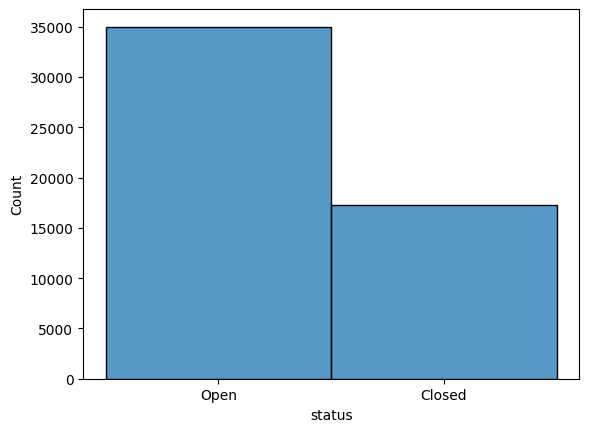

In [ ]:
import seaborn as sns
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
sns.histplot(x="status", data=restaurants)


2. Identify and handle missing, duplicate, or inconsistent data

In [ ]:
restaurants.isnull().sum()

,0
business_id,0
name,0
address,0
city,0
state,0
postal_code,0
latitude,0
longitude,0
stars,0
review_count,0


In [ ]:
restaurants["business_id"].duplicated().sum()
#no duplicates

np.int64(0)

<Axes: xlabel='stars', ylabel='Count'>

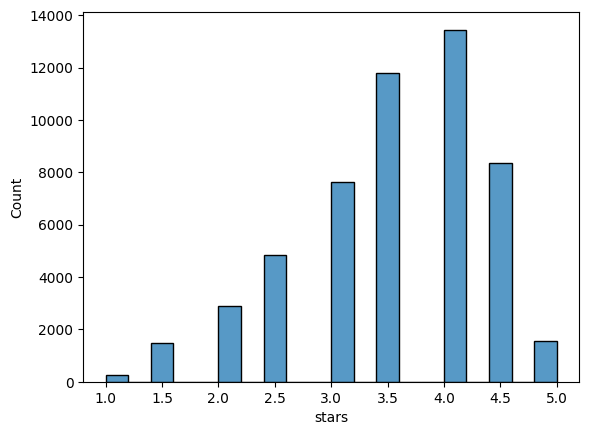

In [ ]:
sns.histplot(restaurants["stars"], bins=20)

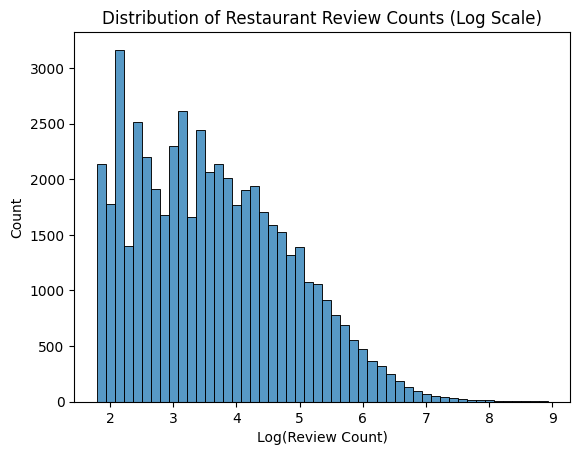

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(np.log1p(restaurants["review_count"]), bins=50)
plt.xlabel("Log(Review Count)")
plt.title("Distribution of Restaurant Review Counts (Log Scale)")
plt.show()

/tmp/ipykernel_226/3401758514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})


Text(0.5, 1.0, 'Distribution of Yelp Star Ratings by Restaurant Status')

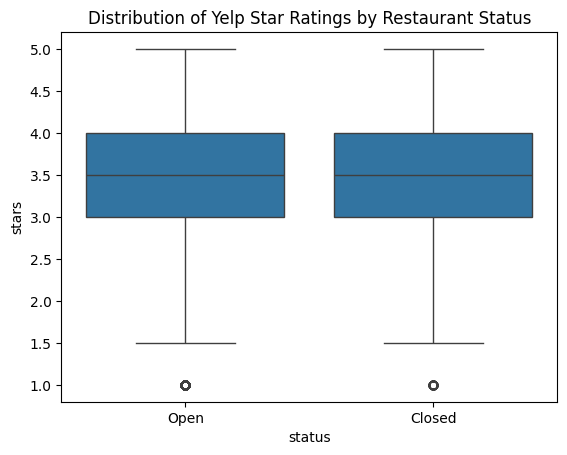

In [ ]:
restaurants["status"] = restaurants["is_open"].map({0: "Closed", 1: "Open"})
sns.boxplot(x="status", y="stars", data=restaurants)
plt.title("Distribution of Yelp Star Ratings by Restaurant Status")

Both open and closed restaurants have a median of 3.5 stars. So Yelp star ratings alone is not a strong way to see if a restaurant stays open

Text(0.5, 1.0, 'Review Count by Restaurant Status')

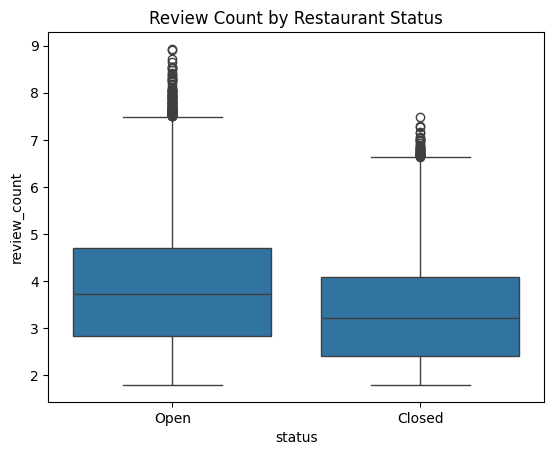

In [ ]:
#do open restaurants have more reviews?
sns.boxplot(x="status", y=np.log1p(restaurants["review_count"]), data=restaurants)
plt.title("Review Count by Restaurant Status")

open restaurants have a higher median review count. (open restaurants have more reviews than closed ones). open restaurants have more high review outliers which can suggest that more popular restaurants can be more likely to be operating.

Text(0.5, 1.0, 'Distribution of Review Counts by Restaurant Status')

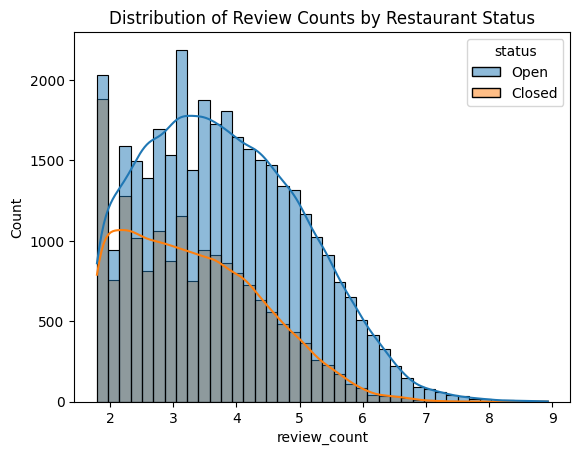

In [ ]:
sns.histplot(data=restaurants, x=np.log1p(restaurants["review_count"]), hue="status", bins=40, kde=True)
plt.title("Distribution of Review Counts by Restaurant Status")

In [ ]:
restaurants[["stars","review_count"]].corr()

,stars,review_count
stars,1.000000,0.155087
review_count,0.155087,1.000000


<Axes: >

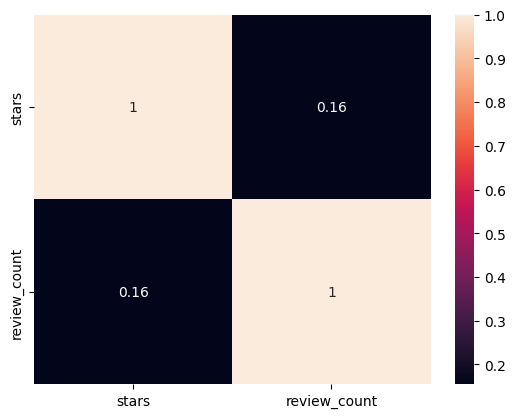

In [ ]:
sns.heatmap(restaurants[["stars","review_count"]].corr(), annot=True)

### Analysis Methods

In [ ]:
## t-test
import numpy as np
from scipy.stats import ttest_ind
restaurants["log_reviews"] = np.log1p(restaurants["review_count"])
open_reviews = restaurants[restaurants["is_open"] == 1]["log_reviews"]
closed_reviews = restaurants[restaurants["is_open"] == 0]["log_reviews"]

ttest_ind(open_reviews, closed_reviews)

/tmp/ipykernel_19278/1188288808.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants["log_reviews"] = np.log1p(restaurants["review_count"])


TtestResult(statistic=np.float64(43.29233160447338), pvalue=np.float64(0.0), df=np.float64(52284.0))

 There is a big difference in review counts between open and closed restaurants -> Open restaurants have significantly higher review counts than closed ones.

 For hyp: More reviews -> more likely to be open

In [ ]:
ttest_ind(
    restaurants[restaurants["is_open"] == 1]["stars"],
    restaurants[restaurants["is_open"] == 0]["stars"]
)

TtestResult(statistic=np.float64(3.4269636183511794), pvalue=np.float64(0.0006108403447429141), df=np.float64(52284.0))

There is a difference in star ratings between open and closed restaurants but the difference is small. So while ratings are different they might not be a string predictor of restaurant operating status.

In [ ]:
## chi-square test
#get categories for restaurants
restaurants["main_category"] = restaurants["categories"].str.split(",").str[0]
#create table for test
#test
from scipy.stats import chi2_contingency
table = pd.crosstab(restaurants["main_category"], restaurants["is_open"])
chi2_contingency(table)

/tmp/ipykernel_19278/3237086195.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants["main_category"] = restaurants["categories"].str.split(",").str[0]


Chi2ContingencyResult(statistic=np.float64(1432.7293314708959), pvalue=np.float64(4.4879560789603175e-109), dof=426, expected_freq=array([[9.25479096e+00, 1.87452090e+01],
       [1.68569407e+01, 3.41430593e+01],
       [3.30528248e-01, 6.69471752e-01],
       [9.91584745e-01, 2.00841525e+00],
       [2.31369774e+00, 4.68630226e+00],
       [3.63581073e+00, 7.36418927e+00],
       [1.12379604e+01, 2.27620396e+01],
       [3.30528248e-01, 6.69471752e-01],
       [3.30528248e-01, 6.69471752e-01],
       [4.06219217e+02, 8.22780783e+02],
       [5.40413686e+02, 1.09458631e+03],
       [3.30528248e-01, 6.69471752e-01],
       [3.30528248e-01, 6.69471752e-01],
       [6.61056497e-01, 1.33894350e+00],
       [3.30528248e-01, 6.69471752e-01],
       [2.31369774e+00, 4.68630226e+00],
       [3.96633898e+00, 8.03366102e+00],
       [2.64422599e+00, 5.35577401e+00],
       [1.98316949e+00, 4.01683051e+00],
       [6.61056497e-01, 1.33894350e+00],
       [6.61056497e-01, 1.33894350e+00],
       [

Null hyp: Restaurant category and is_open are independent.

Results: p-value = 4.4879560789603175e-109 -> extremely small

There is a statistically significant relationship between restaurant category and operating status. Reject null hyp. -> Some restaurant categories are more likely to be open or closed than others.

